In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime, timedelta
import random
from scipy.signal import savgol_filter
from collections import defaultdict

from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource
from bokeh.io import output_notebook
from bokeh.models import LinearAxis, Range1d
output_notebook()

from bokeh.palettes import (
    Colorblind)


Loading BokehJS ...

In [3]:
data_files = ["game_metadata","nintendo","steam","survey_biweekly","survey_daily","survey_intake","timeuse","xbox"]

game_metadata = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/game_metadata.csv", parse_dates=["release_date"])
nintendo = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/nintendo.csv", parse_dates=["session_end", "session_start"])
steam = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/steam.csv", parse_dates=["approximate_session_start", "approximate_session_end"])
survey_biweekly = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_biweekly.csv", parse_dates=["date"])
survey_daily = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_daily.csv", parse_dates=["date"])
survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")
timeuse = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/timeuse.csv", parse_dates=["start_time", "end_time"])
xbox = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/xbox.csv", parse_dates=["session_end", "session_start"])
ios = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/ios.csv")
android = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/android.csv")

steam.rename(columns=
    {
    "approximate_session_start" : "session_start",
    "approximate_session_end" : "session_end",
    "minutes" : "duration"
    }, inplace=True)

user_info = survey_intake.set_index("pid").to_dict("index")
xbox["platform"] = xbox.apply(lambda _: 'xbox', axis=1)
steam["platform"] = steam.apply(lambda _: 'steam', axis=1)
nintendo["platform"] = nintendo.apply(lambda _: 'nintendo', axis=1)

gaming_logs = pd.concat([xbox[["pid", "title_id", "session_start", "session_end", ".had_overlap", "duration", "platform"]], 
           steam[["pid", "title_id", "session_start", "session_end", "duration", "playtime_forever", "platform"]],
           nintendo[["pid",	"title_id",	"session_start",	"session_end",	"duration", "platform"]]
           ], ignore_index=True)

/tmp/ipykernel_41820/1731244082.py:8: DtypeWarning: Columns (10: local_timezone, 38: android_uses_family, 39: ios_uses_family, 41: xbox_uses_family, 51: neuro_diag_tourette, 54: neuro_diag_nvld, 56: neuro_diag_prefer_not_say, 60: neuro_iden_dyslexia, 62: neuro_iden_dyscalculia, 63: neuro_iden_tourette, 65: neuro_iden_spd, 66: neuro_iden_nvld, 68: neuro_iden_prefer_not_say, 74: care_prefer_not_say, 75: care_other, 78: wemwbs_1, 79: wemwbs_2, 80: wemwbs_3, 81: wemwbs_4, 82: wemwbs_5, 83: wemwbs_6, 84: wemwbs_7) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")


In [5]:
survey_biweekly

,pid,wave,date,survey_duration,affective_valence,life_sat,self_reported_daily_play,self_reported_weekly_play,self_reported_biweekly_play,bangs_1,...,wemwbs_2,wemwbs_3,wemwbs_4,wemwbs_5,wemwbs_6,wemwbs_7,played_any_games,wellbeing_index,playtime_2weeks,total_playtime_ever
0,p100362329,1,2024-10-02 14:32:19+00:00,526,65.0,3.0,270.0,1800.0,3600.0,6.0,...,3.0,4.0,5.0,4.0,2.0,3.0,NaN,6.43750,0.000000,0.00
1,p1009647790,1,2025-03-27 21:21:33+00:00,688,52.0,2.0,240.0,1200.0,2400.0,4.0,...,2.0,3.0,3.0,2.0,2.0,3.0,Yes,3.40625,171.944048,38407.35
2,p1009647790,2,2025-04-10 21:15:34+00:00,515,69.0,2.0,240.0,1500.0,3000.0,6.0,...,3.0,3.0,2.0,2.0,2.0,3.0,Yes,4.34375,162.420238,38407.35
3,p1009647790,3,2025-04-24 21:26:57+00:00,443,72.0,2.0,240.0,1800.0,4380.0,4.0,...,3.0,4.0,4.0,3.0,3.0,4.0,Yes,5.28125,292.680952,38407.35
4,p1009647790,4,2025-05-08 21:55:59+00:00,468,74.0,2.0,300.0,1500.0,3000.0,6.0,...,3.0,3.0,2.0,2.0,1.0,2.0,Yes,4.34375,192.841667,38407.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6839,p9998167087,2,2025-06-19 22:49:26+00:00,267,85.0,7.0,60.0,360.0,780.0,7.0,...,4.0,4.0,3.0,4.0,3.0,4.0,Yes,7.62500,0.000000,0.00
6840,p9998167087,3,2025-07-03 20:45:41+00:00,196,82.0,8.0,30.0,180.0,600.0,5.0,...,4.0,4.0,4.0,4.0,3.0,3.0,Yes,7.84375,0.000000,0.00
6841,p9998167087,4,2025-07-18 02:17:06+00:00,249,81.0,6.0,0.0,180.0,420.0,6.0,...,3.0,4.0,3.0,4.0,4.0,4.0,Yes,7.40625,0.000000,0.00
6842,p9998167087,5,2025-08-01 20:00:54+00:00,160,69.0,7.0,30.0,180.0,300.0,6.0,...,3.0,3.0,4.0,4.0,3.0,3.0,Yes,6.84375,0.000000,0.00


In [ ]:
survey_biweekly["wellbeing_index"] = (((survey_biweekly.life_sat * 4)/10) + 
    40 - (survey_biweekly.promis_1 + survey_biweekly.promis_2 + survey_biweekly.promis_3 + survey_biweekly.promis_4 + 
    survey_biweekly.promis_5 + survey_biweekly.promis_6 + survey_biweekly.promis_7 + survey_biweekly.promis_8) + 
    survey_biweekly.wemwbs_1 + survey_biweekly.wemwbs_2 + survey_biweekly.wemwbs_3 + survey_biweekly.wemwbs_4 +  
    survey_biweekly.wemwbs_5 + survey_biweekly.wemwbs_6 + survey_biweekly.wemwbs_7 - 7)/16 * 10/4

def playtime_2weeks(row, gaming_logs):
    return gaming_logs[(gaming_logs.pid == row.pid) & (row.date - timedelta(days=14) < gaming_logs.session_start) & (gaming_logs.session_start < row.date)].duration.sum()/14

survey_biweekly["playtime_2weeks"] = survey_biweekly.apply(playtime_2weeks, args=(gaming_logs,), axis=1)

total_playtime_ever_per_pid = gaming_logs.groupby(by="pid").duration.sum().to_dict()
survey_biweekly["total_playtime_ever"] = survey_biweekly.pid.apply(lambda pid: total_playtime_ever_per_pid.get(pid, 0))


In [4]:
users_with_data = pd.read_csv("users_with_data.csv")
per_pid_2weeks = users_with_data.groupby("pid", as_index=False)[["playtime_2weeks", "wellbeing_index"]].mean()
per_pid_2weeks["neuro_status"] = per_pid_2weeks.pid.apply(lambda pid: user_info[pid]["neuro_diagnosed"])
per_pid_2weeks["age"] = per_pid_2weeks.pid.apply(lambda pid: user_info[pid]["age"])
per_pid_2weeks["gender"] = per_pid_2weeks.pid.apply(lambda pid: user_info[pid]["gender"])
per_pid_2weeks["edu_level"] = per_pid_2weeks.pid.apply(lambda pid: user_info[pid]["edu_level"])
per_pid_2weeks.dropna(inplace=True)
per_pid_2weeks

,pid,playtime_2weeks,wellbeing_index,neuro_status,age,gender,edu_level
1,p1009727917,36.484195,6.000000,No,30,Non-binary,Bachelor's degree
2,p1018587010,0.000000,7.562500,Yes,28,Man,High school graduate or equivalent
4,p1033719717,79.896429,3.156250,Yes,26,Woman,Bachelor's degree
5,p1049789162,24.964286,5.312500,No,29,Man,Bachelor's degree
7,p1052182009,141.189087,7.020833,Yes,24,Woman,High school graduate or equivalent
...,...,...,...,...,...,...,...
1699,p9940084075,135.887500,5.114583,No,32,Non-binary,Some college but no degree
1702,p9964755184,82.953175,3.364583,No,27,Non-binary,Bachelor's degree
1705,p9976509821,172.608710,6.687500,Yes,24,Non-binary,Bachelor's degree
1706,p9979986994,477.739073,6.213542,Prefer not to say,19,Man,High school graduate or equivalent


In [94]:
per_pid_2weeks.gender.unique()

gender_options = {
    "Man": ["Man", "Transgender Man"],
    "Woman": ["Woman", "trans woman", "Trans woman"],
    "Non-Binary" : ["agender", "Agender", "Genderfluid", "gender-fluid", "Bigender Trans Male", "He/They", "Demiman", "Demi-boy", "Non-binary", "transmasc lesbian", "Non-Binary"],
    "No answer" : ["Prefer not to say", "Questioning", "No answer"]
}
gender_options = {value : key for  key, values in gender_options.items() for value in values}
per_pid_2weeks["gender"] = per_pid_2weeks.gender.apply(lambda gender: gender_options[gender])

per_pid_2weeks.gender.value_counts()

gender
Man           345
Woman         231
Non-Binary     85
No answer       2
Name: count, dtype: int64

In [8]:
edu_level = {
    "Bachelor's" : ["Bachelor's degree", "Some college but no degree", "Associate degree"],
    "High School" : ["High school graduate or equivalent"],
    "Master's/Doctorate" : ["Master's degree, professional degree, or doctoral degree"],
    "Less than High School" : ["Less than a high school diploma or equivalent"],
    "No answer" : ["Prefer not to say"]
}

edu_level = {value : key for  key, values in edu_level.items() for value in values}

per_pid_2weeks["edu_level"] = per_pid_2weeks.edu_level.apply(lambda edu: edu_level[edu])
per_pid_2weeks.edu_level.value_counts()

edu_level
Bachelor's               459
High School              134
Master's/Doctorate        57
Less than High School     11
No answer                  2
Name: count, dtype: int64

In [9]:
age_range = {
    "18-20" : np.arange(18, 21),
    "21-25" : np.arange(21, 26),
    "26-30" : np.arange(26, 31),
    "31-35" : np.arange(31, 36),
    "36-40" : np.arange(36, 41),
}
per_pid_2weeks["age_bin"] = per_pid_2weeks.age.apply(lambda age: [key for key,value in age_range.items() if age in value][0])

per_pid_2weeks["playtime_2weeks_hrs"] = per_pid_2weeks.playtime_2weeks/60


In [10]:
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap, factor_mark

# age_bin = sorted(per_pid_2weeks.age_bin.unique())
genders = sorted(per_pid_2weeks.gender.unique())
MARKERS = ['hex', 'circle_x', 'triangle']

p = figure(title = "Wellness v/s Playtime", background_fill_color="#fafafa")
p.xaxis.axis_label = 'Wellness Index'
p.yaxis.axis_label = 'Avg Playtime per 2 weeks (in hours)'

data = ColumnDataSource(per_pid_2weeks)

p.scatter("wellbeing_index", "playtime_2weeks_hrs", source=data,
          legend_group="gender", fill_alpha=0.3, size=12,
          marker=factor_mark('gender', MARKERS, genders),
          color=factor_cmap('gender', 'Category10_4', genders))

p.legend.location = "top_left"
p.legend.title = "Age Range"

show(p)

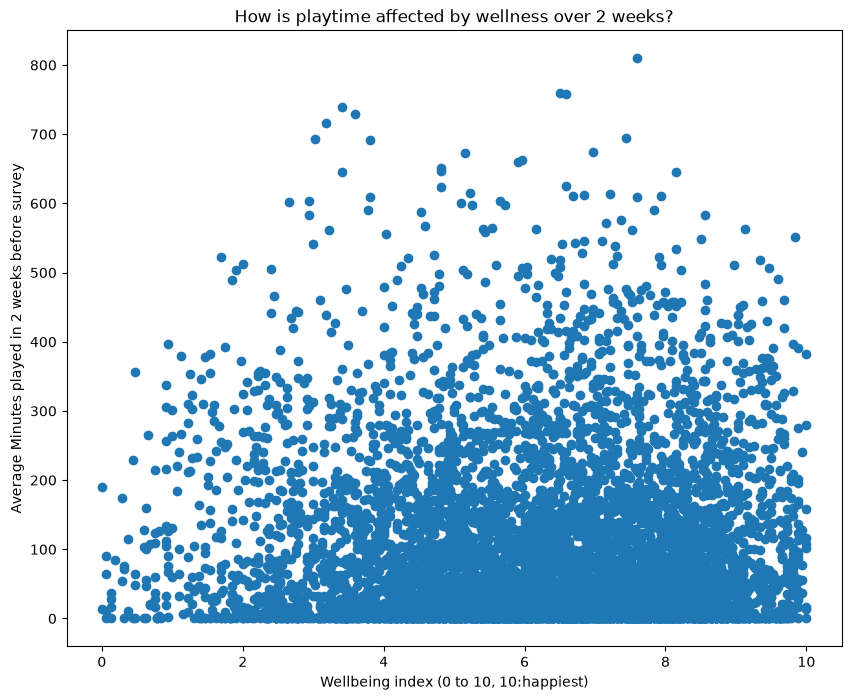

In [23]:
# Wellness v/s playtime graph

# users_with_data = pd.read_csv("users_with_data.csv", parse_dates=["date"])

plt.figure(figsize=(10, 8))
plt.scatter(users_with_data.wellbeing_index, users_with_data.playtime_2weeks)
plt.xlabel("Wellbeing index (0 to 10, 10:happiest)")
plt.ylabel("Average Minutes played in 2 weeks before survey")
plt.title("How is playtime affected by wellness over 2 weeks?")
plt.show()

In [6]:
gaming_logs = pd.read_csv("gaming_logs.csv", parse_dates=["session_start", "session_end"])
users_with_data = pd.read_csv("users_with_data.csv", parse_dates=["date"])

/tmp/ipykernel_7325/3680413823.py:1: DtypeWarning: Columns (4: .had_overlap) have mixed types. Specify dtype option on import or set low_memory=False.
  gaming_logs = pd.read_csv("gaming_logs.csv", parse_dates=["session_start", "session_end"])


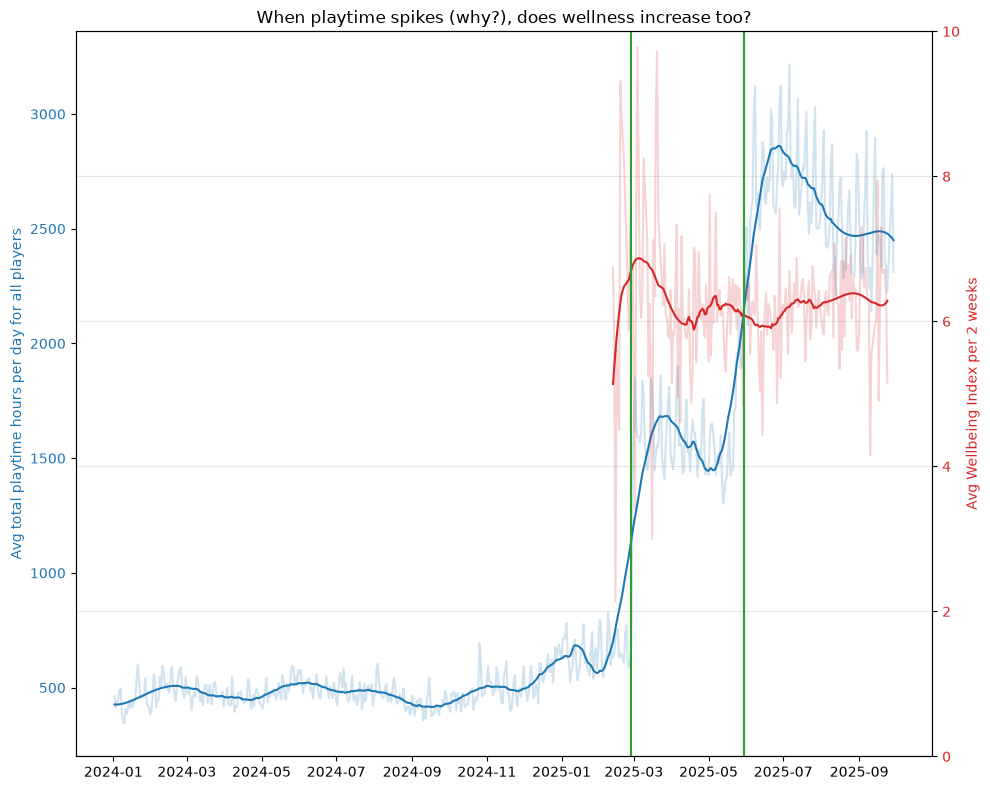

In [46]:
# grouped playtime for all players who answered in survey

per_day_2025 = gaming_logs[(gaming_logs.session_start.dt.date > date(2024, 1, 1)) & (gaming_logs.session_start.dt.date < date(2025, 9, 30))]

log_and_survey = {}
for pid in per_day_2025.pid.unique():
    log_and_survey[pid] = True if pid in users_with_data.pid.to_list() else False

per_day_2025["survey"] = per_day_2025.pid.apply(lambda pid: log_and_survey[pid])
per_day_2025 = per_day_2025[per_day_2025.survey == True]
per_day_2025 = per_day_2025.groupby(per_day_2025.session_start.dt.date, as_index=False).duration.sum()
per_day_2025.rename(columns={"session_start" : "date"}, inplace=True)
per_day_2025.duration = per_day_2025.duration/60

biweekly_wellbeing = users_with_data[["pid", "date", "wellbeing_index"]].reset_index(drop=True)
biweekly_wellbeing.date = biweekly_wellbeing.date.dt.date
biweekly_wellbeing = biweekly_wellbeing.groupby("date", as_index=False).wellbeing_index.mean()
biweekly_wellbeing = biweekly_wellbeing[biweekly_wellbeing.wellbeing_index.notna() == True]

per_day_2025["duration_smooth"] = savgol_filter(per_day_2025.duration, 100, 4)
biweekly_wellbeing["wellbeing_index_smooth"] = savgol_filter(biweekly_wellbeing.wellbeing_index, 100, 6)

fig, ax1 = plt.subplots(figsize=(10,8))

color = "tab:blue"
ax1.set_ylabel("Avg total playtime hours per day for all players", color=color)
ax1.plot(per_day_2025.date, per_day_2025.duration_smooth, c=color)
ax1.tick_params(axis="y", labelcolor=color)

ax1.plot(per_day_2025.date, per_day_2025.duration, c=color, alpha=0.2)

ax2 = ax1.twinx() 
color = "tab:red"
ax2.set_ylabel("Avg Wellbeing Index per 2 weeks", color=color)  
ax2.plot(biweekly_wellbeing.date, biweekly_wellbeing.wellbeing_index_smooth, color=color)
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylim(0, 10)

ax2.plot(biweekly_wellbeing.date, biweekly_wellbeing.wellbeing_index, color=color, alpha=0.2)

plt.axvline(date(2025, 5, 30), c="tab:green")
plt.axvline(date(2025, 2, 27), c="tab:green")
plt.title("When playtime spikes (why?), does wellness increase too?")

fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [47]:
per_day_2025.to_csv("per_day_2025.csv", index=False)
biweekly_wellbeing.to_csv("biweekly_wellbeing.csv", index=False)

In [54]:
source_per_day = ColumnDataSource(per_day_2025)
source_wellbeing = ColumnDataSource(biweekly_wellbeing)

p = figure(
    width=600, height=400, title="Exploring Playtime Spikes and Effect on Wellbeing Index", x_axis_type="datetime",
    x_axis_label="Telemetry Timespan",
    y_axis_label="Total playtime per day (in hours)",
    tooltips=[("Total Playtime", "@duration"), ("Average Wellbeing Index", "@wellbeing_index")]
)

p.extra_y_ranges = {"wellbeing_index_scale": Range1d(start=1, end=10)}
p.add_layout(LinearAxis(y_range_name="wellbeing_index_scale"), 'right')

p.line(
    "date",
    "duration",  # Position columns (required)
    color="green",  # Color column (can be scalar or column name)
    alpha=0.1,  # Transparency (0=transparent, 1=opaque)
    source=source_per_day,  # Data source (ColumnDataSource)
)

p.line(
    "date",
    "duration_smooth",  # Position columns (required)
    color="green",  # Color column (can be scalar or column name)
    alpha=0.8,
    source=source_per_day,  # Data source (ColumnDataSource)
    legend_label="Total Duration"
)

p.line(
    "date",
    "wellbeing_index_smooth",  # Position columns (required)
    color="red",  # Color column (can be scalar or column name)
    alpha=0.8,  # Transparency (0=transparent, 1=opaque)
    source=source_wellbeing,  # Data source (ColumnDataSource)
    legend_label="Wellbeing Index",
    y_range_name="wellbeing_index_scale"
    )

p.line(
    "date",
    "wellbeing_index",  # Position columns (required)
    color="red",  # Color column (can be scalar or column name)
    source=source_wellbeing,  # Data source (ColumnDataSource)
    alpha=0.1,
    y_range_name="wellbeing_index_scale"

    )

p.vspan(x=date(2025, 5, 30), color="blue", legend_label="Observed Spikes")
p.vspan(x=date(2025, 2, 27), color="blue")

p.legend.location = "top_left"

show(p)


In [140]:
game_keywords = game_metadata[["original_name", "keywords"]].set_index("original_name").to_dict(orient="dict")
per_pid = pd.DataFrame(gaming_logs.groupby(["pid", "title_id"], as_index=False).duration.sum())
per_pid = per_pid[per_pid.duration > 1000]
per_pid["gender"] = per_pid.pid.apply(lambda pid: user_info[pid]["gender"])
per_pid["keywords"] = per_pid.title_id.apply(lambda title: game_keywords["keywords"].get(title, 0))
per_pid = per_pid[per_pid.keywords.notna() == True]
per_pid = per_pid[per_pid.gender.isin(["Man", "Woman", "Non-binary"]) == True].reset_index(drop=True)

gender_keyword = defaultdict(dict)
keyword_exp = ["male protagonist", "female protagonist", "magic", "cooking", "pvp", "cozy"]
gender = ["Man", "Woman", "Non-binary"]

for keyword in keyword_exp:
    gender_keyword[keyword].update(per_pid.apply(lambda row: row["gender"] if keyword in row["keywords"] else 0, axis=1).value_counts().to_dict())

gender_keyword_wo_0 = pd.DataFrame(gender_keyword).reset_index().rename(columns={"index" : "gender"})
gender_keyword_wo_0 = gender_keyword_wo_0[gender_keyword_wo_0.gender != 0]
# gender_keyword_wo_0.columns = gender_keyword_wo_0.iloc[0]
# gender_keyword_wo_0 = gender_keyword_wo_0.iloc[1:]
gender_keyword_wo_0

,gender,male protagonist,female protagonist,magic,cooking,pvp,cozy
1,Man,691,264,446,317,429,120
2,Woman,306,100,141,256,156,286
3,Non-binary,71,27,38,33,29,34


In [58]:
survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")
user_info = survey_intake.set_index("pid").to_dict("index")
game_metadata = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/game_metadata.csv", parse_dates=["release_date"])
game_keywords = game_metadata[["original_name", "keywords"]].set_index("original_name").to_dict(orient="dict")
per_pid = pd.DataFrame(gaming_logs.groupby(["pid", "title_id"], as_index=False).duration.sum())
per_pid = per_pid[per_pid.duration > 1000]
per_pid["gender"] = per_pid.pid.apply(lambda pid: user_info[pid]["gender"])
per_pid["keywords"] = per_pid.title_id.apply(lambda title: game_keywords["keywords"].get(title, 0))
per_pid = per_pid[per_pid.keywords.notna() == True]
per_pid = per_pid[per_pid.gender.isin(["Man", "Woman", "Non-binary"]) == True].reset_index(drop=True)
per_pid

/tmp/ipykernel_7325/1045394968.py:1: DtypeWarning: Columns (10: local_timezone, 38: android_uses_family, 39: ios_uses_family, 41: xbox_uses_family, 51: neuro_diag_tourette, 54: neuro_diag_nvld, 56: neuro_diag_prefer_not_say, 60: neuro_iden_dyslexia, 62: neuro_iden_dyscalculia, 63: neuro_iden_tourette, 65: neuro_iden_spd, 66: neuro_iden_nvld, 68: neuro_iden_prefer_not_say, 74: care_prefer_not_say, 75: care_other, 78: wemwbs_1, 79: wemwbs_2, 80: wemwbs_3, 81: wemwbs_4, 82: wemwbs_5, 83: wemwbs_6, 84: wemwbs_7) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")


,pid,title_id,duration,gender,keywords
0,p1003299452,Dead by Daylight,6992.869393,Man,"pvp, gore, atmospheric, survival horror, downl..."
1,p1003299452,NBA 2K26,17875.575856,Man,basketball
2,p1003299452,The Outlast Trials,2662.339621,Man,"psychological horror, character customization,..."
3,p1003299452,War Robots: Frontiers,14535.977892,Man,"futuristic warfare, mech, character customizat..."
4,p1006674997,Diablo® IV,19749.795324,Man,"exploration, wizards, demon, character customi..."
...,...,...,...,...,...
8187,p9996920974,Overwatch® 2,1863.163155,Man,"pvp, pve, controversy"
8188,p9997778313,Animal Crossing New Horizons,1603.916667,Man,"life simulation, dinosaurs, casual, animals, c..."
8189,p9997778313,Mario Kart 8 Deluxe,2613.433333,Man,"yoshi, donkey kong, link, anti-gravity racing,..."
8190,p9997778313,The Legend of Zelda Breath of the Wild,2594.066667,Man,"hunting, post-apocalyptic, crafting, archery, ..."


In [ ]:
# most popular keywords
keywords = [keyword_list.split(",") for keyword_list in per_pid.keywords]
keywords = np.concatenate(keywords).tolist()
keywords = [keyword.strip() for keyword in keywords]

from collections import Counter

keyword_count = Counter(keywords)
keyword_count

Counter({'steam achievements': 1488,
         'crafting': 1479,
         'character customization': 1180,
         'achievements': 1144,
         'steam cloud': 1139,
         'the game awards - game of the year - nominee': 1100,
         'exploration': 1035,
         'day/night cycle': 1013,
         'xbox controller support for pc': 956,
         'steam trading cards': 941,
         '3d': 927,
         'the game awards - nominee': 927,
         'sequel': 914,
         'bees': 878,
         'bow and arrow': 867,
         'controller support': 858,
         'steam': 853,
         'management': 838,
         'digital distribution': 827,
         'the game awards - best multiplayer game - nominee': 819,
         'steam families': 803,
         'male protagonist': 774,
         'the game awards 2017': 768,
         'the game awards - best game direction - nominee': 747,
         'fishing': 700,
         'the game awards - best score or music - nominee': 673,
         'action-adventure': 6

In [ ]:
results = gender_keyword_wo_0.drop(columns=["keyword"]).to_dict()
for k,v in results.items():
    results[k] = list(results[k].values())


{'Man': [691, 264, 446, 317, 429, 120],
 'Woman': [306, 100, 141, 256, 156, 286],
 'Non-binary': [71, 27, 38, 33, 29, 34],
 'keyword': ['male protagonist',
  'female protagonist',
  'magic',
  'cooking',
  'pvp',
  'cozy']}

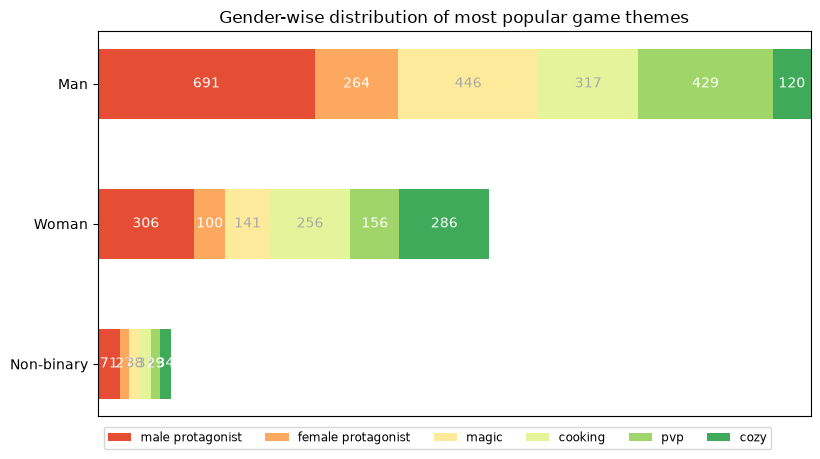

In [ ]:
category_names = keyword_exp
labels =  list(results.keys())
data = np.array(list(results.values()))
data_cum = data.cumsum(axis=1)
category_colors = plt.colormaps['RdYlGn'](
        np.linspace(0.15, 0.85, data.shape[1]))

fig, ax = plt.subplots(figsize=(9.2, 5))
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.set_xlim(0, np.sum(data, axis=1).max())

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.5,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
        ax.bar_label(rects, label_type='center', color=text_color)
ax.legend(ncols=len(category_names), bbox_to_anchor=(0, -0.1),
        loc='lower left', fontsize='small')

ax.set_title("Gender-wise distribution of most popular game themes")
plt.show()


In [105]:
# lists for both categories
# data to list = {"y" : y_list,
# item_of_x = [values]}

Students = ['Ankur', 'Yash', 'Aditya', 'Harshit']
Subjects = ['Operating System', 'Data Structure','Java Programming']
# Initialize data to lists.
data = {'Students': Students,
        'Operating System': [17, 20, 19, 18],
        'Data Structure': [19, 18, 20, 17],
        'Java Programming': [20, 19, 20, 18]}
df = pd.DataFrame(data)
fig.hbar_stack(Subjects,
               y='Students',
               source=ColumnDataSource(df),
        #        color=cols,
               height=0.5,
               legend_label=Subjects)

df

,Students,Operating System,Data Structure,Java Programming
0,Ankur,17,19,20
1,Yash,20,18,19
2,Aditya,19,20,20
3,Harshit,18,17,18


In [203]:
gender_keyword_wo_0_3 = gender_keyword_wo_0.iloc[:,:4]

gender_keyword_wo_0_3["sum"] = gender_keyword_wo_0_3.iloc[:, 1:4].cumsum(axis=1).iloc[:, -1].values
gender_keyword_wo_0_3["male protagonist"] = gender_keyword_wo_0_3["male protagonist"]/gender_keyword_wo_0_3["sum"]
gender_keyword_wo_0_3["female protagonist"] = gender_keyword_wo_0_3["female protagonist"]/gender_keyword_wo_0_3["sum"]
gender_keyword_wo_0_3["magic"] = gender_keyword_wo_0_3["magic"]/gender_keyword_wo_0_3["sum"]
gender_keyword_wo_0_3.drop(columns=["sum"], inplace=True)
gender_keyword_wo_0_3

gender_keyword_wo_0_3.to_csv("keywords_gender.csv", index=False)

In [ ]:
Colorblind_Vibrant = ["#ee3377", "#0072b2", "#33bbee", "#fff563", "#009e73", "#2F2F2F", "#f8f4c7"]

('#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311')

In [ ]:
.button-56 {
  align-items: center;
  background-color: #fee6e3;
  border: 2px solid #111;
  border-radius: 8px;
  box-sizing: border-box;
  color: #111;
  cursor: pointer;
  display: flex;
  font-family: Inter,sans-serif;
  font-size: 16px;
  height: 48px;
  justify-content: center;
  line-height: 24px;
  max-width: 100%;
  padding: 0 25px;
  position: relative;
  text-align: center;
  text-decoration: none;
  user-select: none;
  -webkit-user-select: none;
  touch-action: manipulation;
}

.button-56:after {
  background-color: #111;
  border-radius: 8px;
  content: "";
  display: block;
  height: 48px;
  left: 0;
  width: 100%;
  position: absolute;
  top: -2px;
  transform: translate(8px, 8px);
  transition: transform .2s ease-out;
  z-index: -1;
}

.button-56:hover:after {
  transform: translate(0, 0);
}

.button-56:active {
  background-color: #ffdeda;
  outline: 0;
}

.button-56:hover {
  outline: 0;
}

@media (min-width: 768px) {
  .button-56 {
    padding: 0 40px;
  }
}

ValueError: positional arguments are not allowed

In [205]:
keyword_exp = ["male protagonist", "female protagonist", "magic"]
gender = ["Man", "Woman", "Non-binary"]

from bokeh.palettes import Spectral3
source = ColumnDataSource(gender_keyword_wo_0_3)

# plot data in Stack manner of bar type
fig = figure(y_range=gender,
             height=500,
             title="Gender-wise preference of popular game themes",
             x_range=[0,1],
             tooltips=[("Male Protagonist", "@male protagonist")]
            )

fig.hbar_stack(keyword_exp,
               y='gender',
               source=source,
               height=0.5,
               color = Spectral3,
               legend_label=keyword_exp)

# Display Stack Graph
fig.legend.orientation = "horizontal"
fig.legend.location = "bottom"
show(fig)

In [ ]:
# Export Files

users_with_data.to_csv("users_with_data.csv", index=False)
gaming_logs.to_csv("gaming_logs.csv", index=False)

#### Hourly avg playtime in a day


In [24]:
hour_logs = pd.concat([gaming_logs, pd.DataFrame(np.arange(24).reshape(1,24))])[:-1]


def hourly_duration(df):
    if df.duration < 60:
        df[df.session_start.hour] = df.duration
    else:
        start_hour = df.session_start.hour
        end_hour = df.session_end.hour
        for hour in np.arange(start_hour, end_hour+1):
            if hour == end_hour:
                df[hour] = df.session_end.minute
            elif hour == start_hour:
                df[hour] = 60 - df.session_start.minute   
            else:
                df[hour] = 60

    return df

new_hourly_logs = hour_logs.apply(hourly_duration, axis=1)


In [25]:
new_hourly_logs[new_hourly_logs.duration > 100][["session_start", "session_end", "duration", 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23]]

,session_start,session_end,duration,0,1,2,3,4,5,6,...,14,15,16,17,18,19,20,21,22,23
5,2022-05-07 17:25:00+00:00,2022-05-07 19:10:00+00:00,105.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,35.0,60.0,10.0,NaN,NaN,NaN,NaN
22,2022-05-21 01:35:00+00:00,2022-05-21 04:10:00+00:00,155.000000,NaN,25.0,60.0,60.0,10.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2022-05-22 15:40:00+00:00,2022-05-22 17:50:00+00:00,130.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,20.0,60.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN
36,2022-06-03 20:00:00+00:00,2022-06-03 22:00:00+00:00,120.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,60.0,60.0,0.0,NaN
37,2022-06-04 13:25:00+00:00,2022-06-04 15:45:00+00:00,140.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.0,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1734150,2023-05-26 16:01:41+00:00,2023-05-26 21:25:17+00:00,323.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,59.0,60.0,60.0,60.0,60.0,25.0,NaN,NaN
1734154,2023-05-27 19:05:25+00:00,2023-05-27 21:10:32+00:00,125.116667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,55.0,60.0,10.0,NaN,NaN
1734157,2023-05-28 17:43:44+00:00,2023-05-28 22:21:54+00:00,278.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,17.0,60.0,60.0,60.0,60.0,21.0,NaN
1734158,2023-05-29 17:42:20+00:00,2023-05-29 20:27:46+00:00,165.433333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.0,60.0,60.0,27.0,NaN,NaN,NaN


In [31]:
new_hourly_logs[np.arange(0,24)] = new_hourly_logs[np.arange(0,24)].fillna(0)
new_hourly_logs

,pid,title_id,session_start,session_end,.had_overlap,duration,platform,playtime_forever,0,1,...,14,15,16,17,18,19,20,21,22,23
0,p1049789162,9D2BEC81-A614-42F5-B00A-C350C2A215EE,2025-07-08 18:22:20+00:00,2025-07-08 18:29:26+00:00,False,7.100000,xbox,NaN,0.0,0.0,...,0.0,0.000000,0.0,0.0,7.1,0.0,0.0,0.0,0.0,0.0
1,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-01 00:00:00+00:00,2022-05-01 00:15:00+00:00,False,15.000000,xbox,NaN,15.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-03 21:40:00+00:00,2022-05-03 22:50:00+00:00,False,70.000000,xbox,NaN,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,20.0,50.0,0.0
3,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-06 20:15:00+00:00,2022-05-06 21:30:00+00:00,False,75.000000,xbox,NaN,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,45.0,30.0,0.0,0.0
4,p1092839713,B5A4EA0E-2901-420F-8DAF-0D00CCBA5D2F,2022-05-07 15:10:00+00:00,2022-05-07 16:00:00+00:00,False,50.000000,xbox,NaN,0.0,0.0,...,0.0,50.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1734155,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-28 10:31:03+00:00,2023-05-28 12:02:33+00:00,NaN,91.500000,nintendo,NaN,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1734156,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-28 15:41:42+00:00,2023-05-28 16:18:02+00:00,NaN,36.333333,nintendo,NaN,0.0,0.0,...,0.0,36.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1734157,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-28 17:43:44+00:00,2023-05-28 22:21:54+00:00,NaN,278.166667,nintendo,NaN,0.0,0.0,...,0.0,0.000000,0.0,17.0,60.0,60.0,60.0,60.0,21.0,0.0
1734158,p9997778313,The Legend of Zelda Tears of the Kingdom,2023-05-29 17:42:20+00:00,2023-05-29 20:27:46+00:00,NaN,165.433333,nintendo,NaN,0.0,0.0,...,0.0,0.000000,0.0,18.0,60.0,60.0,27.0,0.0,0.0,0.0


In [48]:
new_hourly_logs[new_hourly_logs.platform == "steam"][20].mean()

np.float64(2.708294198727918)

In [33]:
per_pid_hourly = new_hourly_logs.groupby("pid", as_index=False)[np.arange(0,24)].mean()
per_pid_hourly

,pid,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,p1003299452,1.949510,2.187280,2.707614,2.974694,2.912405,2.713135,2.286827,1.808686,1.447684,...,0.487802,0.391158,0.647133,0.910481,1.176165,1.982490,2.616311,2.855716,2.967324,2.039679
1,p1006674997,1.755018,0.920919,0.793689,0.573564,0.691699,0.362455,0.323273,0.084870,0.140076,...,0.546989,0.379700,0.945360,2.862353,4.385824,4.958348,6.280580,6.664150,6.268016,3.649830
2,p1009647790,2.020878,3.062232,3.430202,3.957980,4.136569,4.065190,3.499294,2.962697,1.884168,...,0.058309,0.000000,0.000000,0.000000,0.120184,0.222930,0.465856,0.959783,1.556935,1.914536
3,p1009727917,0.262069,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.595655,1.176335,2.264168,3.525976,7.892270,7.983565,9.646593,7.714345,4.463046,1.749883
4,p1010540528,0.872667,1.114533,1.353600,0.524133,1.109867,0.150800,0.214133,0.098533,0.000000,...,0.529200,1.020667,1.028133,1.101067,1.172667,0.936400,0.638933,0.500133,0.429600,0.856667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3763,p9995617863,0.662411,0.249060,0.124413,0.000000,0.119718,0.049296,0.135625,0.306042,0.619634,...,1.717903,1.876691,2.478421,2.072553,1.944849,3.155583,6.576865,8.469573,5.137465,1.782322
3764,p9995673703,3.911174,1.805166,1.725490,6.313725,3.627451,2.960784,1.235294,0.960784,0.313725,...,0.000000,0.000000,0.000000,0.000000,2.413936,1.666667,4.412135,4.055251,1.843137,2.058824
3765,p9995771948,1.360657,1.105183,1.333262,1.283012,1.373906,1.421897,1.747233,0.968000,0.576000,...,1.832482,2.009418,1.364724,1.763397,1.867270,1.222403,3.614875,4.384440,2.766299,1.148098
3766,p9996920974,2.187253,2.466429,2.608319,2.013419,1.758459,1.359099,0.931921,0.602388,0.372802,...,1.117242,1.406055,1.776193,2.622714,2.878768,3.337482,3.352375,3.054284,2.422138,1.846571


In [43]:
per_platform_hourly = new_hourly_logs.groupby("platform")[np.arange(0,24)].mean().T
per_platform_hourly

platform,nintendo,steam,xbox
0,1.007488,1.907159,5.272818
1,1.424865,2.256405,5.390070
2,1.485942,2.243950,5.492151
3,1.340781,2.113713,5.358101
4,1.148164,1.885758,4.888821
5,0.954194,1.599866,4.014913
6,0.820818,1.328457,3.106123
7,0.787467,1.095634,2.304514
8,0.843734,0.924479,1.666926
9,0.995563,0.848643,1.220375


In [105]:

gender_options = {
    "Man": ["Man", "Transgender Man", "Trans Man", "Trans man"],
    "Woman": ["Woman", "trans woman", "Trans woman"],
    "Non-Binary" : ["agender", "Agender", "Genderfluid", "genderqueer", "genderfluid", "gender-fluid", "Bigender Trans Male", "He/They", "Demiman", "Demi-boy", "Non-binary", "transmasc lesbian", "Non-Binary", "Trans-Femme Non-Binary", "Trans Masculine", "Abinary transmasc"],
    "No answer" : ["Prefer not to say", "Questioning", "No answer"]
}
gender_options = {value : key for  key, values in gender_options.items() for value in values}

per_pid_hourly["employment"] = per_pid_hourly.pid.apply(lambda pid: user_info[pid]["employment"])
per_pid_hourly["gender"] = per_pid_hourly.pid.apply(lambda pid: user_info[pid]["gender"])
per_pid_hourly["gender"] = per_pid_hourly.gender.apply(lambda gender: gender_options[gender])
per_pid_hourly["dependents"] = per_pid_hourly.pid.apply(lambda pid: False if isinstance(user_info[pid]["dependents"], float) else True)

per_pid_hourly

,pid,0,1,2,3,4,5,6,7,8,...,17,18,19,20,21,22,23,employment,gender,dependents
0,p1003299452,1.949510,2.187280,2.707614,2.974694,2.912405,2.713135,2.286827,1.808686,1.447684,...,0.910481,1.176165,1.982490,2.616311,2.855716,2.967324,2.039679,Working full-time,Man,False
1,p1006674997,1.755018,0.920919,0.793689,0.573564,0.691699,0.362455,0.323273,0.084870,0.140076,...,2.862353,4.385824,4.958348,6.280580,6.664150,6.268016,3.649830,Working full-time,Man,False
2,p1009647790,2.020878,3.062232,3.430202,3.957980,4.136569,4.065190,3.499294,2.962697,1.884168,...,0.000000,0.120184,0.222930,0.465856,0.959783,1.556935,1.914536,Student,Non-Binary,False
3,p1009727917,0.262069,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.525976,7.892270,7.983565,9.646593,7.714345,4.463046,1.749883,Working full-time,Non-Binary,False
4,p1010540528,0.872667,1.114533,1.353600,0.524133,1.109867,0.150800,0.214133,0.098533,0.000000,...,1.101067,1.172667,0.936400,0.638933,0.500133,0.429600,0.856667,Working full-time,Man,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3763,p9995617863,0.662411,0.249060,0.124413,0.000000,0.119718,0.049296,0.135625,0.306042,0.619634,...,2.072553,1.944849,3.155583,6.576865,8.469573,5.137465,1.782322,Working full-time,Man,False
3764,p9995673703,3.911174,1.805166,1.725490,6.313725,3.627451,2.960784,1.235294,0.960784,0.313725,...,0.000000,2.413936,1.666667,4.412135,4.055251,1.843137,2.058824,Working full-time,Man,False
3765,p9995771948,1.360657,1.105183,1.333262,1.283012,1.373906,1.421897,1.747233,0.968000,0.576000,...,1.763397,1.867270,1.222403,3.614875,4.384440,2.766299,1.148098,Not currently employed,Man,True
3766,p9996920974,2.187253,2.466429,2.608319,2.013419,1.758459,1.359099,0.931921,0.602388,0.372802,...,2.622714,2.878768,3.337482,3.352375,3.054284,2.422138,1.846571,Student,Man,False


In [113]:
genders = ["Man", "Woman", "Non-binary"]

In [127]:
per_pid_hourly[per_pid_hourly.gender == "Woman"][np.arange(0,24)].mean()

0     1.811600
1     2.287783
2     2.403815
3     2.229590
4     1.971928
5     1.631469
6     1.284101
7     0.958316
8     0.865717
9     0.823357
10    0.806000
11    0.850976
12    0.997658
13    1.202773
14    1.388106
15    1.701988
16    1.922892
17    2.083397
18    2.483083
19    2.933268
20    3.158400
21    2.990024
22    2.572367
23    1.647128
dtype: float64

In [ ]:
dashes = ['solid', 'dashed', 'dotted']
greys = ['black', 'dimgray', 'darkgray']
hours = np.arange(0,24)

platform = figure(title='Platform', x_axis_label='Hour (local)', y_axis_label='Minutes per player',
           y_range=(0, 10),
           tooltips=[('hour', '$x{0}'), ('minutes', '$y{0.0}')])

for idx, p in enumerate(per_platform_hourly.columns):
    platform.line(hours, per_platform_hourly[p],
                  legend_label=p, 
                  line_dash=dashes[idx], 
                  color=greys[idx], 
                  line_width=2)

g = figure(title='Gender', x_axis_label='Hour (local)', y_axis_label='Minutes per player',
           y_range=(0, 10),
           tooltips=[('hour', '$x{0}'), ('minutes', '$y{0.0}')])

for idx, p in enumerate(genders):
    g.line(hours, per_pid_hourly[per_pid_hourly.gender == p][np.arange(0,24)].mean(),
                  legend_label=p, 
                  line_dash=dashes[idx], 
                  color=greys[idx], 
                  line_width=2)

dependents = figure(title='Depdendents', x_axis_label='Hour (local)', y_axis_label='Minutes per player',
           y_range=(0, 10),
           tooltips=[('hour', '$x{0}'), ('minutes', '$y{0.0}')])

for idx, p in enumerate([True, False]):
    dependents.line(hours, per_pid_hourly[per_pid_hourly.dependents == p][np.arange(0,24)].mean(),
                  legend_label=f"{p}", 
                  line_dash=dashes[idx], 
                  color=greys[idx], 
                  line_width=2)



plots = [platform, g, dependents]
grid = gridplot(plots, ncols=2, width=600, height=400)
show(grid)
show(platform)

g is ready
g is ready
g is ready
